# Task 3 Working Prototype
## Jurisdiction-Aware AI Credit Fairness Checker

Huang Sining | G2505429H | SINING001@e.ntu.edu.sg

This notebook demonstrates Option A (Working Prototype) with additional Option C quantitative elements.
It covers synthetic data generation, credit model training, explainability (coefficient-based and SHAP),
US and UK compliance checks, threshold sensitivity analysis, and drift simulation.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data_generator import generate_synthetic_applicants
from src.model_pipeline import train_credit_model, MODEL_FEATURES
from src.explainability import (
    explain_rejections,
    feature_importance_from_logistic_model,
    shap_global_summary,
    shap_local_explanation,
)
from src.compliance_checker import run_compliance_check, print_report, approval_rate_by_group
from src.sensitivity_analysis import run_threshold_sensitivity
from src.drift_simulation import simulate_recession_drift, compare_baseline_and_drift
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap.initjs()

## 1. Generate Synthetic Applicant Data

1,500 synthetic applicants are generated with a deliberate bias scenario.
Sensitive attributes (nationality, ethnicity, religion, marital_status) are retained
for post-decision fairness auditing only — they are excluded from model training.

In [2]:
df = generate_synthetic_applicants(n=1500, seed=42, bias_scenario=True)
print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df["defaulted"].mean():.3f}')
df.head()

Dataset shape: (1500, 13)
Default rate: 0.314


,applicant_id,nationality,ethnicity,religion,marital_status,employment_status,age,annual_income,credit_score,loan_amount,debt_to_income,default_probability_true,defaulted
0,1,India,Group_B,None/Not disclosed,single,full_time,38,65740.62,529,9316.56,0.420,0.551297,1
1,2,Germany,Group_D,Religion_C,married,full_time,23,65765.61,654,28118.66,0.197,0.272170,0
2,3,India,Group_A,Religion_A,married,part_time,36,21892.15,663,18248.44,0.254,0.352224,0
3,4,Canada,Group_A,Religion_C,married,full_time,27,72185.75,573,11959.40,0.053,0.231480,1
4,5,US,Group_C,Religion_A,single,full_time,35,30548.77,645,22967.32,0.388,0.496213,0


## 2. Train AI Credit Risk Model

Logistic regression pipeline with StandardScaler (numeric) and OneHotEncoder (categorical).
Model features: age, annual_income, credit_score, loan_amount, debt_to_income, employment_status.
Sensitive attributes are strictly excluded from training.

In [3]:
results, model, metrics = train_credit_model(df, threshold=0.50)
print('Model metrics:')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Model metrics:
  accuracy: 0.7707
  roc_auc: 0.7843
  approval_rate: 0.7667
  decision_threshold: 0.5000


## 3. Explainability: Global Feature Importance (Logistic Regression Coefficients)

Coefficient magnitudes show which features drive approval decisions globally.
Note: this is a linear approximation of importance. SHAP provides model-consistent
importance values and is covered in Section 4.

In [4]:
fi = feature_importance_from_logistic_model(model)
print('Top features by absolute coefficient magnitude:')
fi.head(10)

Top features by absolute coefficient magnitude:


,feature,coefficient,absolute_importance
7,credit_score,-0.917948,0.917948
6,annual_income,-0.739814,0.739814
1,employment_status_part_time,-0.403991,0.403991
8,loan_amount,0.378296,0.378296
3,employment_status_student,0.336438,0.336438
4,employment_status_unemployed,0.284353,0.284353
9,debt_to_income,0.235534,0.235534
0,employment_status_full_time,-0.206523,0.206523
5,age,0.073852,0.073852
2,employment_status_self_employed,-0.012283,0.012283


## 4. Explainability: SHAP (SHapley Additive exPlanations)

SHAP provides model-consistent feature attributions. For this logistic regression,
`shap.LinearExplainer` computes exact SHAP values without approximation.

**Global summary plot** shows which features push predictions toward approval or rejection,
and their distribution across the applicant population.

**Local waterfall plot** shows why a single rejected applicant was turned down,
with each feature's contribution to pushing the model prediction above or below
the approval threshold. This is the kind of model-derived explanation that the
CFPB adverse action guidance requires for AI credit decisions.

In [5]:
# Compute SHAP values for the full dataset
shap_result = shap_global_summary(model, df)
shap_values = shap_result['shap_values']
X_transformed = shap_result['X_transformed']
feature_names = shap_result['feature_names']

print(f'SHAP values computed for {shap_values.shape[0]} applicants across {shap_values.shape[1]} features')

SHAP values computed for 1500 applicants across 10 features


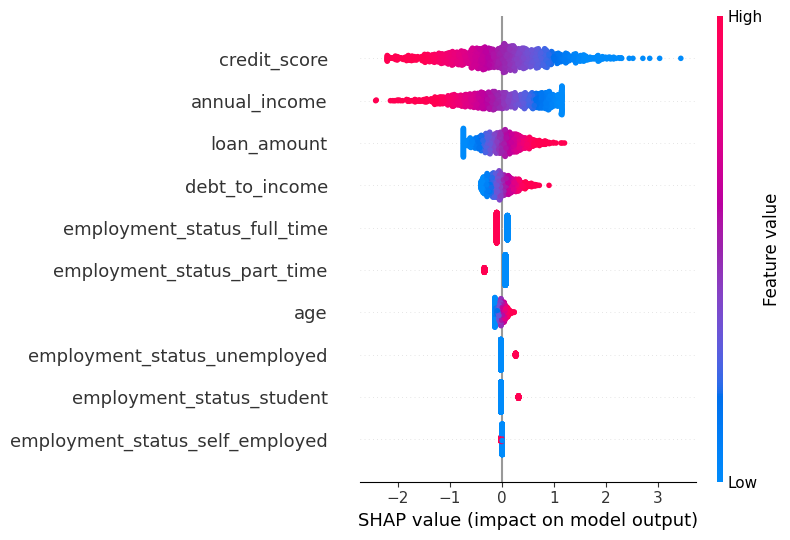

In [6]:
# Global SHAP summary plot (beeswarm)
# High SHAP value = feature pushes prediction toward default (rejection)
# Low SHAP value  = feature pushes prediction toward approval
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type='dot',
    show=True,
    max_display=10,
)

Applicant 0: credit_score=529, annual_income=65741, debt_to_income=0.420
Model predicted default probability: 0.548
Decision (0=rejected): 0



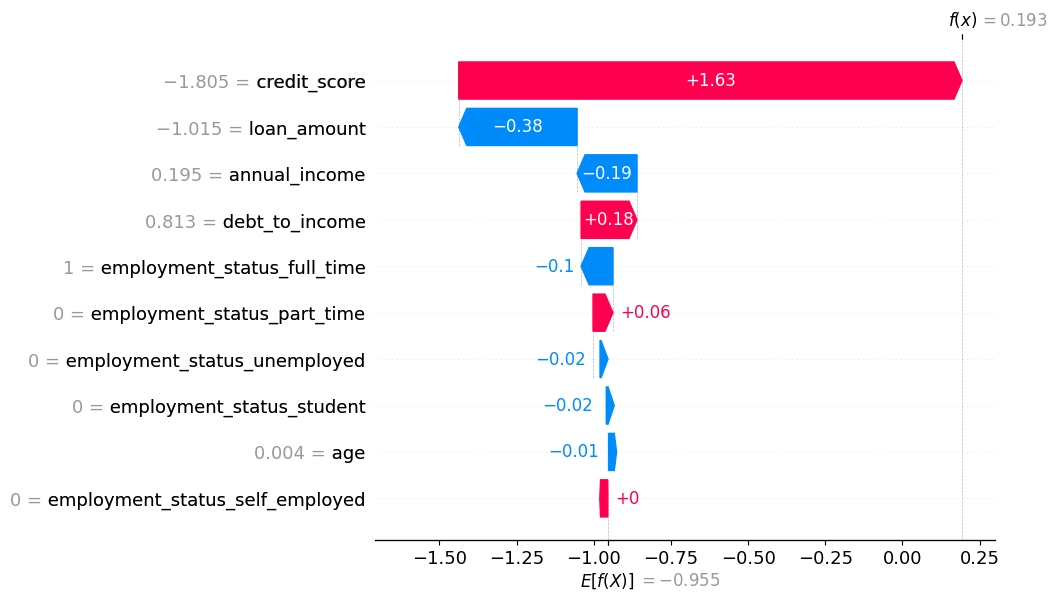

In [7]:
# Local SHAP explanation for a single rejected applicant
rejected_indices = results[results['approved'] == 0].index.tolist()
example_idx = rejected_indices[0]

local = shap_local_explanation(model, df, example_idx)

print(f'Applicant {example_idx}: credit_score={df.loc[example_idx, "credit_score"]:.0f}, '
      f'annual_income={df.loc[example_idx, "annual_income"]:.0f}, '
      f'debt_to_income={df.loc[example_idx, "debt_to_income"]:.3f}')
print(f'Model predicted default probability: {results.loc[example_idx, "predicted_default_probability"]:.3f}')
print(f'Decision (0=rejected): {results.loc[example_idx, "approved"]}')
print()

# Waterfall plot: shows each feature's contribution to this individual prediction
shap_exp = shap.Explanation(
    values=local['shap_values_single'],
    base_values=local['expected_value'],
    data=local['X_single'],
    feature_names=local['feature_names'],
)
shap.waterfall_plot(shap_exp, show=True)

## 5. Explainability: Rule-Based Adverse Action Reasons

The prototype also generates human-readable adverse action reasons using feature-threshold
heuristics. These are a simplified proxy for the model-derived SHAP explanations above.
In a production system, the SHAP waterfall values (Section 4) would be the primary
mechanism for generating specific and meaningful adverse action reasons, as required
by the CFPB guidance cited in the US jurisdiction configuration.

In [8]:
explanations = explain_rejections(results, sample_size=10)
explanations

,applicant_id,reason_1,reason_2,reason_3
0,1,Credit score below internal benchmark,,
1,5,Overall predicted default risk exceeds approva...,,
2,8,Income below affordability benchmark,Employment status increases repayment uncertainty,
3,10,Credit score below internal benchmark,Income below affordability benchmark,Employment status increases repayment uncertainty
4,11,Credit score below internal benchmark,Requested loan amount is high relative to profile,
5,14,Income below affordability benchmark,Requested loan amount is high relative to profile,
6,21,Credit score below internal benchmark,Debt-to-income ratio is high,Income below affordability benchmark
7,22,Credit score below internal benchmark,Income below affordability benchmark,Employment status increases repayment uncertainty
8,26,Credit score below internal benchmark,Income below affordability benchmark,Employment status increases repayment uncertainty
9,29,Credit score below internal benchmark,Income below affordability benchmark,Employment status increases repayment uncertainty


## 6. US Compliance Report

US configuration: ECOA / Regulation B-style fair lending.
Approval disparity threshold: 0.80 (four-fifths rule convention).
Requires adverse action reasons and bias testing.

In [9]:
us_report = run_compliance_check(
    results, jurisdiction='US',
    model_card_available=True,
    human_oversight_available=False,
    bias_testing_completed=True,
    drift_monitoring_available=True,
)
print_report(us_report)

Jurisdiction: US
Regime: ECOA / Regulation B-style fair lending review
Rule version: US-2026-05-demo | Last reviewed: 2026-05-22
Philosophy: Outcome fairness, adverse action explanation, and post-hoc review
Overall status: No major issues detected
------------------------------------------------------------------------------------------
Source: US-CFPB-ADVERSE-ACTION | CFPB guidance on AI-driven credit decisions and adverse action notices
Operational test: Rejected applicants must receive specific and meaningful adverse action reasons.
Source: US-REG-B | ECOA / Regulation B fair lending logic
Operational test: Check whether approval outcomes differ materially across protected or proxy groups.
------------------------------------------------------------------------------------------
No findings.


## 7. UK Compliance Report

UK configuration: FCA Consumer Duty outcome monitoring.
Approval disparity threshold: 0.90 (stricter than US).
Additionally requires human oversight evidence and Consumer Duty outcome monitoring.

**Key finding**: the same model output that clears the US check fails the UK check
because the nationality disparity ratio (0.898) and ethnicity disparity ratio (0.858)
both fall below the stricter 0.90 UK threshold.

In [10]:
uk_report = run_compliance_check(
    results, jurisdiction='UK',
    model_card_available=True,
    human_oversight_available=True,
    bias_testing_completed=True,
    drift_monitoring_available=True,
)
print_report(uk_report)

Jurisdiction: UK
Regime: FCA Consumer Duty and responsible lending outcome monitoring
Rule version: UK-2026-05-demo | Last reviewed: 2026-05-22
Philosophy: Consumer outcomes, responsible lending, explainability, and board-level accountability
Overall status: Review Required
------------------------------------------------------------------------------------------
Source: UK-FCA-CONSUMER-DUTY | FCA Consumer Duty outcome monitoring
Operational test: Monitor whether credit decisions create poor outcomes for customer groups.
Source: UK-FCA-IMPLEMENTATION-PLANS | FCA Consumer Duty implementation planning
Operational test: Require evidence that governance, monitoring, and remediation are embedded in the product lifecycle.
------------------------------------------------------------------------------------------
1. [Medium] Approval disparity detected for nationality (DISPARITY-MONITORING)
   Disparity ratio 0.898 is below UK threshold 0.90.
2. [Medium] Approval disparity detected for ethnici

## 8. Approval Rates by Demographic Group

Showing the underlying group-level approval rates that drive the disparity ratio calculations.

In [11]:
for attr in ['ethnicity', 'nationality', 'religion']:
    rates = approval_rate_by_group(results, attr)
    disparity = rates['approval_rate'].min() / rates['approval_rate'].max()
    print(f'--- {attr} | disparity ratio: {disparity:.3f} ---')
    print(rates.to_string(index=False))
    print()

--- ethnicity | disparity ratio: 0.858 ---
ethnicity  approval_rate   n
  Group_D          0.671 152
  Group_C          0.764 229
  Group_A          0.779 756
  Group_B          0.782 363

--- nationality | disparity ratio: 0.898 ---
nationality  approval_rate   n
    Germany          0.727 154
         UK          0.750 148
         US          0.766 483
      India          0.767 193
     Canada          0.768  99
     France          0.775 120
      China          0.780 182
  Singapore          0.810 121

--- religion | disparity ratio: 0.988 ---
          religion  approval_rate   n
        Religion_C          0.761 293
        Religion_B          0.766 372
None/Not disclosed          0.767 369
        Religion_A          0.770 466



## 9. Threshold Sensitivity Analysis

How do compliance conclusions change as the model decision threshold varies?
The US threshold (0.80) and UK threshold (0.90) are shown as reference lines.

In [12]:
sensitivity = run_threshold_sensitivity(df)
print(sensitivity.to_string(index=False))

 threshold  approval_rate  roc_auc  ethnicity_disparity_ratio  religion_disparity_ratio  nationality_disparity_ratio
      0.35       0.626667 0.784278                   0.749598                  0.954886                     0.861446
      0.40       0.682000 0.784278                   0.766620                  0.986684                     0.865169
      0.45       0.724667 0.784278                   0.790199                  0.989530                     0.870200
      0.50       0.766667 0.784278                   0.857719                  0.987936                     0.897959
      0.55       0.807333 0.784278                   0.889549                  0.973949                     0.939935
      0.60       0.844667 0.784278                   0.909041                  0.969255                     0.913327


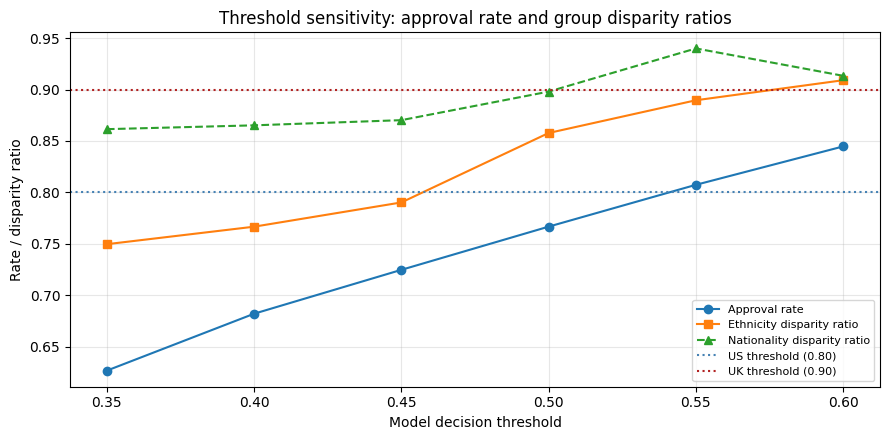

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sensitivity['threshold'], sensitivity['approval_rate'], marker='o', label='Approval rate')
ax.plot(sensitivity['threshold'], sensitivity['ethnicity_disparity_ratio'], marker='s', label='Ethnicity disparity ratio')
ax.plot(sensitivity['threshold'], sensitivity['nationality_disparity_ratio'], marker='^', linestyle='--', label='Nationality disparity ratio')
ax.axhline(0.80, linestyle=':', color='steelblue', label='US threshold (0.80)')
ax.axhline(0.90, linestyle=':', color='firebrick', label='UK threshold (0.90)')
ax.set_xlabel('Model decision threshold')
ax.set_ylabel('Rate / disparity ratio')
ax.set_title('Threshold sensitivity: approval rate and group disparity ratios')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Drift Simulation

A recession scenario is simulated by applying an income shock (-12%) and
debt-to-income inflation (+18%) to the **same baseline applicant population**.
This isolates the effect of the economic shock from random variation in population composition.

In [14]:
drift_df = simulate_recession_drift(df)
drift_comparison = compare_baseline_and_drift(df, drift_df, threshold=0.50)
print(drift_comparison.to_string(index=False))

       scenario  approval_rate  roc_auc  ethnicity_disparity_ratio  religion_disparity_ratio
       baseline       0.766667 0.784278                   0.857719                  0.987936
recession_drift       0.720667      NaN                   0.799012                  0.983842


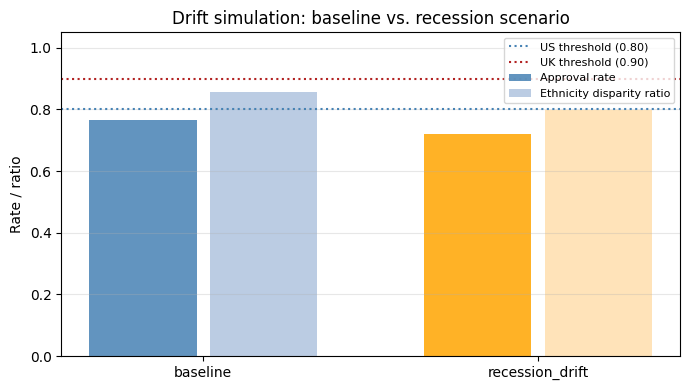

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
x = [0, 1]
labels = drift_comparison['scenario'].tolist()
ax.bar([xi - 0.18 for xi in x], drift_comparison['approval_rate'], width=0.32,
       color=['steelblue', 'orange'], alpha=0.85, label='Approval rate')
ax.bar([xi + 0.18 for xi in x], drift_comparison['ethnicity_disparity_ratio'], width=0.32,
       color=['lightsteelblue', 'navajowhite'], alpha=0.85, label='Ethnicity disparity ratio')
ax.axhline(0.80, linestyle=':', color='steelblue', label='US threshold (0.80)')
ax.axhline(0.90, linestyle=':', color='firebrick', label='UK threshold (0.90)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Rate / ratio')
ax.set_title('Drift simulation: baseline vs. recession scenario')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Interpretation

**Jurisdiction divergence**: The same logistic regression model evaluated on identical synthetic data
returns different compliance outcomes depending on which regulatory configuration is active.
The US configuration clears because all group disparity ratios exceed 0.80.
The UK configuration triggers review because nationality (0.898) and ethnicity (0.858) disparity
ratios fall below the stricter 0.90 threshold.

**Explainability**: SHAP provides model-consistent feature attributions that satisfy the spirit of
the CFPB adverse action guidance. The waterfall plot in Section 4 shows how each feature
contributed to an individual rejection decision — this is the direction a production tool
would take, as opposed to the heuristic thresholds used in the simplified adverse action module.

**Drift**: Applying a recession income shock to the same baseline population reduces approval rates
and alters group disparity ratios. A model validated as compliant under one economic environment
may produce materially different fairness outcomes after an economic shock, requiring continuous
monitoring rather than a one-time validation exercise.